In [ ]:
import tensorflow as tf
import os

gpus = tf.config.list_physical_devices('GPU')
print("GPUs available:", gpus)

tf.keras.mixed_precision.set_global_policy('mixed_float16')
print("Mixed precision policy:", tf.keras.mixed_precision.global_policy())

os.environ["TF_ENABLE_ONEDNN_OPTS"] = "0"
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'
AUTOTUNE = tf.data.AUTOTUNE

2026-03-22 12:30:13.525966: I tensorflow/core/util/port.cc:113] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-03-22 12:30:13.684166: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9261] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2026-03-22 12:30:13.684205: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2026-03-22 12:30:13.707817: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1515] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2026-03-22 12:30:13.769102: I tensorflow/core/platform/cpu_feature_guar

GPUs available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
INFO:tensorflow:Mixed precision compatibility check (mixed_float16): OK
Your GPU will likely run quickly with dtype policy mixed_float16 as it has compute capability of at least 7.0. Your GPU: NVIDIA RTX 4000 SFF Ada Generation, compute capability 8.9
Mixed precision policy: <Policy "mixed_float16">


2026-03-22 12:30:15.474870: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:901] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
2026-03-22 12:30:15.533434: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:901] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
2026-03-22 12:30:15.535102: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:901] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import cv2
import warnings
warnings.filterwarnings('ignore')

from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import classification_report, confusion_matrix

In [ ]:
IMG_SIZE        = 384
BATCH_SIZE      = 16           # 16 is safer for 384px on T4/V100
EPOCHS_FROZEN   = 10           # Phase 1: head only
EPOCHS_FINETUNE = 25           # Phase 2: unfreeze top layers
NUM_CLASSES     = 5
SEED            = 42

TRAIN_DIR  = "ddr_dataset/dr_grading/train"
VALID_DIR  = "ddr_dataset/dr_grading/valid"



# Your folders are named 0,1,2,3,4 — so use these as labels too
CLASS_NAMES = ['No_DR', 'Mild', 'Moderate', 'Severe', 'Proliferative_DR']
FOLDER_NAMES = ['0', '1', '2', '3', '4']

In [ ]:
train_ds_raw = tf.keras.utils.image_dataset_from_directory(
    TRAIN_DIR,
    label_mode="categorical",
    image_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    shuffle=True,
    seed=SEED
)

val_ds_raw = tf.keras.utils.image_dataset_from_directory(
    VALID_DIR,
    label_mode="categorical",
    image_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    shuffle=False
)

print("Class names:", train_ds_raw.class_names)
print("Train batches:", len(train_ds_raw))
print("Val batches  :", len(val_ds_raw))

Found 6260 files belonging to 5 classes.


2026-03-22 12:30:38.355782: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:901] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
2026-03-22 12:30:38.357627: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:901] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
2026-03-22 12:30:38.359093: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:901] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-

Found 2503 files belonging to 5 classes.
Class names: ['0', '1', '2', '3', '4']
Train batches: 392
Val batches  : 157


In [ ]:
print("=" * 45)
print("Class Distribution")
print("=" * 45)

train_labels = []
for idx, folder_name in enumerate(FOLDER_NAMES):          # ← use FOLDER_NAMES
    cls_path = os.path.join(TRAIN_DIR, folder_name)       # ← correct path
    n = len(os.listdir(cls_path))
    train_labels.extend([idx] * n)
    print(f"  {CLASS_NAMES[idx]:22s}  {n:5d} images")

print("-" * 45)

train_labels = np.array(train_labels)

cw = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(train_labels),
    y=train_labels
)
class_weight_dict = dict(enumerate(cw))

print("\nClass Weights (to handle imbalance):")
for k, v in class_weight_dict.items():
    print(f"  {CLASS_NAMES[k]:22s}  {v:.4f}")

Class Distribution
  No_DR                    3133 images
  Mild                      315 images
  Moderate                 2238 images
  Severe                    118 images
  Proliferative_DR          456 images
---------------------------------------------

Class Weights (to handle imbalance):
  No_DR                   0.3996
  Mild                    3.9746
  Moderate                0.5594
  Severe                  10.6102
  Proliferative_DR        2.7456


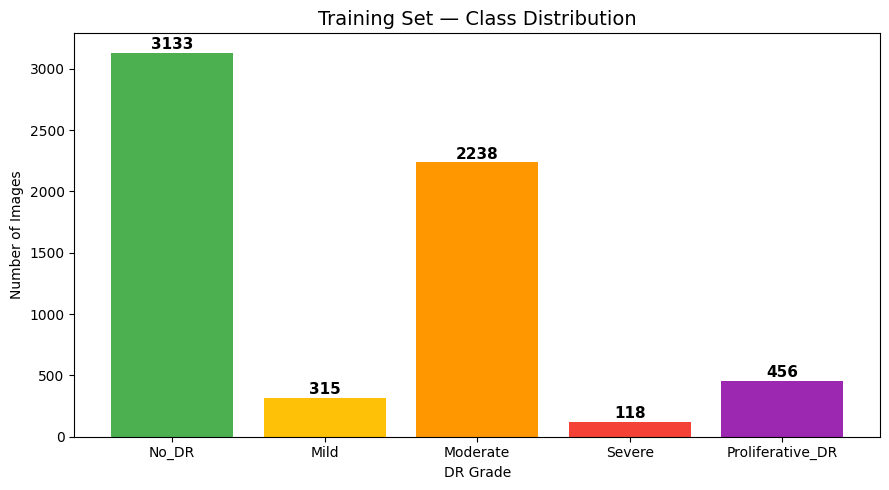

In [ ]:
counts = []
for idx, cls_name in enumerate(train_ds_raw.class_names):
    cls_path = os.path.join(TRAIN_DIR, cls_name)
    counts.append(len(os.listdir(cls_path)))

plt.figure(figsize=(9, 5))
bars = plt.bar(CLASS_NAMES, counts, color=['#4CAF50','#FFC107','#FF9800','#F44336','#9C27B0'])
plt.title("Training Set — Class Distribution", fontsize=14)
plt.ylabel("Number of Images")
plt.xlabel("DR Grade")
for bar, count in zip(bars, counts):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 30,
             str(count), ha='center', fontsize=11, fontweight='bold')
plt.tight_layout()
plt.savefig("class_distribution.png", dpi=150)
plt.show()

In [ ]:
# CLAHE for a single image
def apply_clahe(image):
    image = tf.cast(image, tf.uint8).numpy()

    lab = cv2.cvtColor(image, cv2.COLOR_RGB2LAB)
    l, a, b = cv2.split(lab)

    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8,8))
    l_enhanced = clahe.apply(l)

    enhanced = cv2.merge([l_enhanced, a, b])
    enhanced = cv2.cvtColor(enhanced, cv2.COLOR_LAB2RGB)

    return enhanced.astype(np.float32)


# Apply CLAHE to a batch
def tf_clahe(images, labels):

    def _clahe(img):
        img = tf.py_function(apply_clahe, [img], tf.float32)
        img.set_shape([IMG_SIZE, IMG_SIZE, 3])
        return img

    images = tf.map_fn(_clahe, images, fn_output_signature=tf.float32)

    return images, labels

In [ ]:
data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal_and_vertical"),
    tf.keras.layers.RandomRotation(0.05),
    tf.keras.layers.RandomZoom(0.1),
    tf.keras.layers.RandomContrast(0.2),
    tf.keras.layers.RandomBrightness(0.1),
], name="augmentation")

norm = tf.keras.layers.Rescaling(1./255)

# --- Build final pipelines ---
train_ds = (
    train_ds_raw
    .map(tf_clahe, num_parallel_calls=AUTOTUNE)
    .map(lambda x, y: (data_augmentation(x, training=True), y),  # NO norm
         num_parallel_calls=AUTOTUNE)
    .prefetch(AUTOTUNE)
)
val_ds = (
    val_ds_raw
    .map(tf_clahe, num_parallel_calls=AUTOTUNE)
    .prefetch(AUTOTUNE)   # NO norm
)
print("Train pipeline ready.")
print("Val pipeline ready.")

Train pipeline ready.
Val pipeline ready.


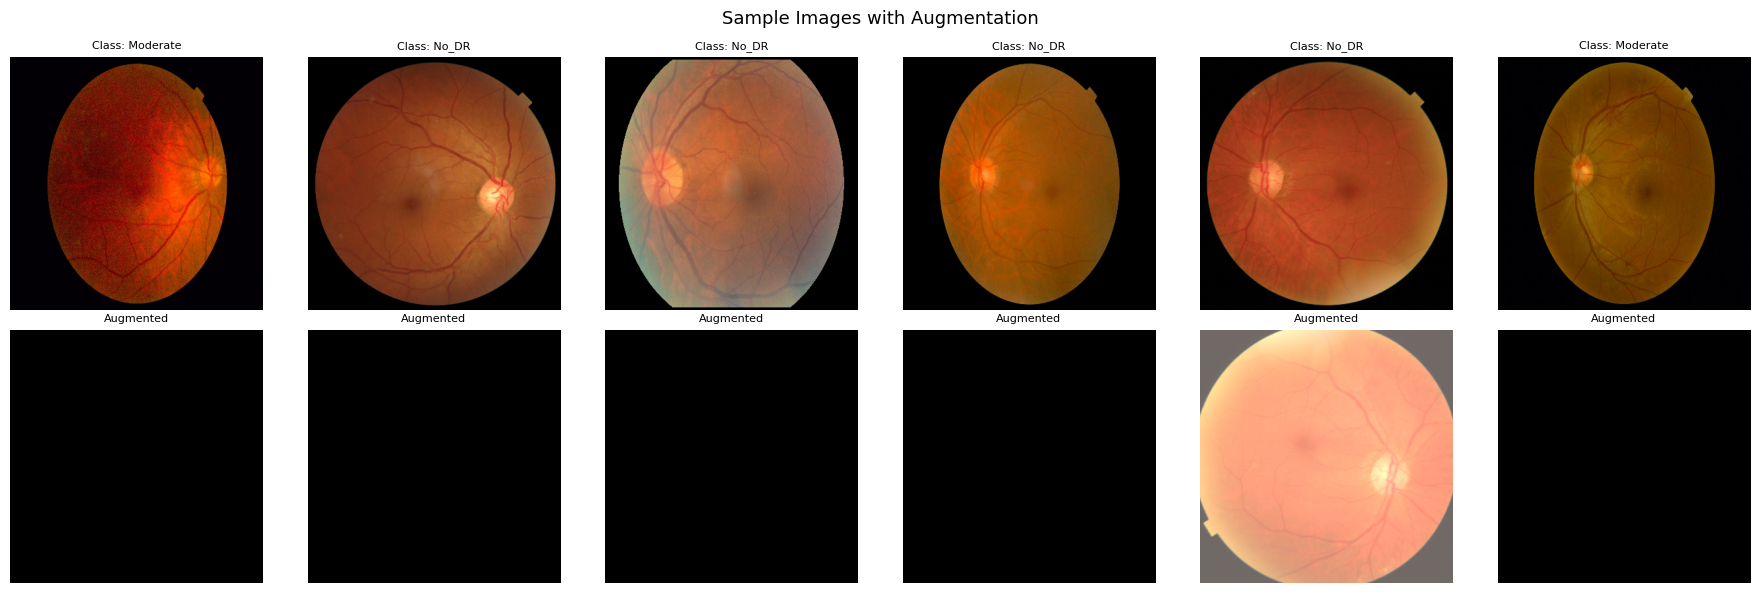

In [ ]:
sample_imgs, sample_lbls = next(iter(train_ds_raw))

fig, axes = plt.subplots(2, 6, figsize=(18, 6))

for i in range(6):
    # Original
    axes[0, i].imshow(sample_imgs[i].numpy().astype(np.uint8))
    axes[0, i].set_title(f"Class: {CLASS_NAMES[np.argmax(sample_lbls[i].numpy())]}", fontsize=8)
    axes[0, i].axis('off')

    # Augmented
    aug_img = data_augmentation(norm(sample_imgs[i:i+1]), training=True)[0].numpy()

    axes[1, i].imshow(np.clip(aug_img.astype(np.float32), 0, 1))
    axes[1, i].set_title("Augmented", fontsize=8)
    axes[1, i].axis('off')

axes[0, 0].set_ylabel("Original", fontsize=11)
axes[1, 0].set_ylabel("Augmented", fontsize=11)

plt.suptitle("Sample Images with Augmentation", fontsize=13)
plt.tight_layout()
plt.savefig("augmentation_preview.png", dpi=150)
plt.show()

In [ ]:
class QuadraticWeightedKappa(tf.keras.metrics.Metric):
    """
    Cohen's Kappa with quadratic weighting.
    Official metric for DR grading competitions (Kaggle EyePACS, APTOS).
    Target: QWK > 0.80 is good; > 0.85 is excellent.
    """
    def __init__(self, num_classes=5, name='qwk', **kwargs):
        super().__init__(name=name, **kwargs)
        self.num_classes = num_classes
        self.cm = self.add_weight(
            name='cm',
            shape=(num_classes, num_classes),
            initializer='zeros'
        )

    def update_state(self, y_true, y_pred, sample_weight=None):
        yt = tf.cast(tf.argmax(y_true, axis=1), tf.int32)
        yp = tf.cast(tf.argmax(y_pred, axis=1), tf.int32)
        cm = tf.math.confusion_matrix(yt, yp, num_classes=self.num_classes)
        self.cm.assign_add(tf.cast(cm, tf.float32))

    def result(self):
        n  = self.num_classes
        w  = tf.cast([[(i-j)**2 / (n-1)**2 for j in range(n)] for i in range(n)], tf.float32)
        ht = tf.reduce_sum(self.cm, axis=1, keepdims=True)
        hp = tf.reduce_sum(self.cm, axis=0, keepdims=True)
        E  = tf.matmul(ht, hp) / (tf.reduce_sum(self.cm) + 1e-8)
        num   = tf.reduce_sum(w * self.cm)
        denom = tf.reduce_sum(w * E)
        return 1.0 - num / (denom + 1e-8)

    def reset_state(self):
        self.cm.assign(tf.zeros((self.num_classes, self.num_classes)))

In [ ]:
base_model = tf.keras.applications.EfficientNetB4(
    include_top=False,
    weights="imagenet",
    input_shape=(IMG_SIZE, IMG_SIZE, 3)
)
base_model.trainable = False   # Frozen for Phase 1

# ── Custom Head
inputs  = tf.keras.Input(shape=(IMG_SIZE, IMG_SIZE, 3))
x       = base_model(inputs, training=False)
x       = tf.keras.layers.GlobalAveragePooling2D()(x)
x       = tf.keras.layers.BatchNormalization()(x)
x       = tf.keras.layers.Dropout(0.4)(x)
x       = tf.keras.layers.Dense(256, activation="relu", dtype="float32")(x)
x       = tf.keras.layers.Dropout(0.3)(x)
outputs = tf.keras.layers.Dense(
    NUM_CLASSES, activation="softmax", dtype="float32", name="predictions"
)(x)

model = tf.keras.Model(inputs, outputs)

print(f"Total params    : {model.count_params():,}")
print(f"Trainable params: {sum(tf.size(v).numpy() for v in model.trainable_variables):,}")
model.summary()

Total params    : 18,141,284
Trainable params: 463,877
Model: "model"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_2 (InputLayer)        [(None, 384, 384, 3)]     0         
                                                                 
 efficientnetb4 (Functional  (None, 12, 12, 1792)      17673823  
 )                                                               
                                                                 
 global_average_pooling2d (  (None, 1792)              0         
 GlobalAveragePooling2D)                                         
                                                                 
 batch_normalization (Batch  (None, 1792)              7168      
 Normalization)                                                  
                                                                 
 dropout (Dropout)           (None, 1792)              0         
      

In [ ]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=3e-4),
    loss=tf.keras.losses.CategoricalCrossentropy(label_smoothing=0.05),
    metrics=["accuracy", QuadraticWeightedKappa(NUM_CLASSES)]
)

callbacks_phase1 = [
    tf.keras.callbacks.ModelCheckpoint(
        "best_phase1.keras",
        monitor="val_qwk", mode="max",
        save_best_only=True, verbose=1
    ),
    tf.keras.callbacks.EarlyStopping(
        monitor="val_qwk", patience=5,
        mode="max", restore_best_weights=True, verbose=1
    ),
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss", factor=0.5,
        patience=3, min_lr=1e-6, verbose=1
    ),
    tf.keras.callbacks.CSVLogger("log_phase1.csv")
]

import sys

sys.stderr = open(os.devnull, "w")
history1 = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS_FROZEN,
    class_weight=class_weight_dict,
    callbacks=callbacks_phase1
)

print(f"\nBest val_qwk (Phase 1): {max(history1.history['val_qwk']):.4f}")

Epoch 1/10


2026-03-22 12:36:07.170407: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:454] Loaded cuDNN version 8906
Corrupt JPEG data: 38 extraneous bytes before marker 0xd9
Corrupt JPEG data: 34 extraneous bytes before marker 0xd9
Corrupt JPEG data: 40 extraneous bytes before marker 0xd9
2026-03-22 12:36:09.435895: I external/local_xla/xla/service/service.cc:168] XLA service 0x7c41c4003860 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
2026-03-22 12:36:09.435933: I external/local_xla/xla/service/service.cc:176]   StreamExecutor device (0): NVIDIA RTX 4000 SFF Ada Generation, Compute Capability 8.9


  1/392 [..............................] - ETA: 53:34 - loss: 3.2193 - accuracy: 0.1875 - qwk: -0.2392

2026-03-22 12:36:09.481131: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1774182969.592069     192 device_compiler.h:186] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


 55/392 [===>..........................] - ETA: 27s - loss: 2.0674 - accuracy: 0.3239 - qwk: 0.2612

...

Corrupt JPEG data: 35 extraneous bytes before marker 0xd9


194/392 [=============>................] - ETA: 17s - loss: 0.9708 - accuracy: 0.5593 - qwk: 0.6138

Corrupt JPEG data: 37 extraneous bytes before marker 0xd9


391/392 [============================>.] - ETA: 0s - loss: 0.9816 - accuracy: 0.5724 - qwk: 0.6324
Epoch 10: val_qwk improved from 0.77259 to 0.77565, saving model to best_phase1.keras
392/392 [==============================] - 48s 121ms/step - loss: 0.9814 - accuracy: 0.5720 - qwk: 0.6320 - val_loss: 1.0600 - val_accuracy: 0.6241 - val_qwk: 0.7756 - lr: 1.5000e-04

Best val_qwk (Phase 1): 0.7756


Corrupt JPEG data: 38 extraneous bytes before marker 0xd9
Corrupt JPEG data: 34 extraneous bytes before marker 0xd9
Corrupt JPEG data: 40 extraneous bytes before marker 0xd9
Corrupt JPEG data: 34 extraneous bytes before marker 0xd9
Corrupt JPEG data: 40 extraneous bytes before marker 0xd9
Corrupt JPEG data: 40 extraneous bytes before marker 0xd9
Corrupt JPEG data: 35 extraneous bytes before marker 0xd9
Corrupt JPEG data: 37 extraneous bytes before marker 0xd9
Corrupt JPEG data: 38 extraneous bytes before marker 0xd9
Corrupt JPEG data: 34 extraneous bytes before marker 0xd9
Corrupt JPEG data: 40 extraneous bytes before marker 0xd9
Corrupt JPEG data: 34 extraneous bytes before marker 0xd9
Corrupt JPEG data: 40 extraneous bytes before marker 0xd9
Corrupt JPEG data: 40 extraneous bytes before marker 0xd9
Corrupt JPEG data: 35 extraneous bytes before marker 0xd9
Corrupt JPEG data: 37 extraneous bytes before marker 0xd9
Corrupt JPEG data: 38 extraneous bytes before marker 0xd9
Corrupt JPEG d

In [ ]:
# Unfreeze top 60 layers of EfficientNetB4
base_model.trainable = True
for layer in base_model.layers[:-60]:
    layer.trainable = False

trainable = sum(1 for l in base_model.layers if l.trainable)
print(f"Trainable base layers: {trainable} / {len(base_model.layers)}")

# MUST recompile after changing trainable layers
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),  # 30x lower than Phase 1!
    loss=tf.keras.losses.CategoricalCrossentropy(label_smoothing=0.05),
    metrics=["accuracy", QuadraticWeightedKappa(NUM_CLASSES)]
)

callbacks_phase2 = [
    tf.keras.callbacks.ModelCheckpoint(
        "best_final.keras",
        monitor="val_qwk", mode="max",
        save_best_only=True, verbose=1
    ),
    tf.keras.callbacks.EarlyStopping(
        monitor="val_qwk", patience=8,
        mode="max", restore_best_weights=True, verbose=1
    ),
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss", factor=0.3,
        patience=4, min_lr=1e-7, verbose=1
    ),
    tf.keras.callbacks.CSVLogger("log_phase2.csv")
]

print("=" * 50)
print("PHASE 2 — Fine-tuning top 60 layers")
print("=" * 50)

history2 = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS_FINETUNE,
    class_weight=class_weight_dict,
    callbacks=callbacks_phase2
)

print(f"\nBest val_qwk (Phase 2): {max(history2.history['val_qwk']):.4f}")

Trainable base layers: 60 / 475
PHASE 2 — Fine-tuning top 60 layers
Epoch 1/25
392/392 [==============================] - ETA: 0s - loss: 0.9345 - accuracy: 0.5752 - qwk: 0.6389
Epoch 1: val_qwk improved from -inf to 0.78842, saving model to best_final.keras
392/392 [==============================] - 60s 127ms/step - loss: 0.9345 - accuracy: 0.5752 - qwk: 0.6389 - val_loss: 0.9815 - val_accuracy: 0.6612 - val_qwk: 0.7884 - lr: 1.0000e-05
Epoch 2/25
391/392 [============================>.] - ETA: 0s - loss: 0.9239 - accuracy: 0.5841 - qwk: 0.6527
Epoch 2: val_qwk did not improve from 0.78842
392/392 [==============================] - 50s 126ms/step - loss: 0.9236 - accuracy: 0.5840 - qwk: 0.6522 - val_loss: 0.9911 - val_accuracy: 0.6596 - val_qwk: 0.7869 - lr: 1.0000e-05
Epoch 3/25
391/392 [============================>.] - ETA: 0s - loss: 0.8905 - accuracy: 0.6061 - qwk: 0.6715
Epoch 3: val_qwk improved from 0.78842 to 0.79141, saving model to best_final.keras
392/392 [================

In [ ]:
# Reload best phase 1 model instead of the phase 2 one
best_model = tf.keras.models.load_model('best_phase1.keras',
    custom_objects={'QuadraticWeightedKappa': QuadraticWeightedKappa})

# Unfreeze ALL layers — let the full network adapt
base_model = best_model.layers[1]   # EfficientNetB4 is layer index 1
base_model.trainable = True

# Only freeze BatchNorm layers to keep pretrained statistics stable
for layer in base_model.layers:
    if isinstance(layer, tf.keras.layers.BatchNormalization):
        layer.trainable = False

trainable = sum(1 for l in base_model.layers if l.trainable)
print(f"Trainable layers: {trainable} / {len(base_model.layers)}")

# Recompile with slightly higher LR
best_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=3e-5),  # 3x higher than before
    loss=tf.keras.losses.CategoricalCrossentropy(label_smoothing=0.05),
    metrics=['accuracy', QuadraticWeightedKappa(NUM_CLASSES)]
)

cb_aggressive = [
    tf.keras.callbacks.ModelCheckpoint('best_aggressive.keras', monitor='val_qwk',
        mode='max', save_best_only=True, verbose=1),
    tf.keras.callbacks.EarlyStopping(monitor='val_qwk', patience=10,
        mode='max', restore_best_weights=True, verbose=1),
    tf.keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5,
        patience=4, min_lr=1e-7, verbose=1)
]

history3 = best_model.fit(
    train_ds, validation_data=val_ds,
    epochs=30,
    class_weight=class_weight_dict,
    callbacks=cb_aggressive
)
print(f"Best val_qwk: {max(history3.history['val_qwk']):.4f}")

Trainable layers: 379 / 475
Epoch 1/30
392/392 [==============================] - ETA: 0s - loss: 1.0434 - accuracy: 0.5589 - qwk: 0.6368
Epoch 1: val_qwk improved from -inf to 0.78920, saving model to best_aggressive.keras
392/392 [==============================] - 139s 299ms/step - loss: 1.0434 - accuracy: 0.5589 - qwk: 0.6368 - val_loss: 1.0017 - val_accuracy: 0.6356 - val_qwk: 0.7892 - lr: 3.0000e-05
Epoch 2/30
392/392 [==============================] - ETA: 0s - loss: 0.9318 - accuracy: 0.5968 - qwk: 0.6814
Epoch 2: val_qwk did not improve from 0.78920
392/392 [==============================] - 117s 296ms/step - loss: 0.9318 - accuracy: 0.5968 - qwk: 0.6814 - val_loss: 1.1465 - val_accuracy: 0.6296 - val_qwk: 0.7702 - lr: 3.0000e-05
Epoch 3/30
392/392 [==============================] - ETA: 0s - loss: 0.8537 - accuracy: 0.6252 - qwk: 0.7052
Epoch 3: val_qwk improved from 0.78920 to 0.80299, saving model to best_aggressive.keras
392/392 [==============================] - 120s 303ms

In [ ]:
# Load best model and keep training — it's still improving!
best_model = tf.keras.models.load_model('best_aggressive.keras',
    custom_objects={'QuadraticWeightedKappa': QuadraticWeightedKappa})

# Same setup but more epochs and stronger regularization
for layer in best_model.layers:
    if hasattr(layer, 'layers'):  # it's the base_model
        for sub in layer.layers:
            if isinstance(sub, tf.keras.layers.BatchNormalization):
                sub.trainable = False

best_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=2e-6),  # very small, continue smoothly
    loss=tf.keras.losses.CategoricalCrossentropy(label_smoothing=0.1),  # more smoothing
    metrics=['accuracy', QuadraticWeightedKappa(NUM_CLASSES)]
)

cb_continue = [
    tf.keras.callbacks.ModelCheckpoint('best_final_v2.keras', monitor='val_qwk',
        mode='max', save_best_only=True, verbose=1),
    tf.keras.callbacks.EarlyStopping(monitor='val_qwk', patience=12,
        mode='max', restore_best_weights=True, verbose=1),
    tf.keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5,
        patience=5, min_lr=1e-8, verbose=1)
]

history4 = best_model.fit(
    train_ds, validation_data=val_ds,
    epochs=20,
    class_weight=class_weight_dict,
    callbacks=cb_continue
)
print(f"Best val_qwk: {max(history4.history['val_qwk']):.4f}")

Epoch 1/20
392/392 [==============================] - ETA: 0s - loss: 0.5920 - accuracy: 0.8992 - qwk: 0.8970
Epoch 1: val_qwk improved from -inf to 0.83767, saving model to best_final_v2.keras
392/392 [==============================] - 136s 294ms/step - loss: 0.5920 - accuracy: 0.8992 - qwk: 0.8970 - val_loss: 0.9582 - val_accuracy: 0.7827 - val_qwk: 0.8377 - lr: 2.0000e-06
Epoch 2/20
392/392 [==============================] - ETA: 0s - loss: 0.5867 - accuracy: 0.9005 - qwk: 0.9020
Epoch 2: val_qwk improved from 0.83767 to 0.83992, saving model to best_final_v2.keras
392/392 [==============================] - 117s 297ms/step - loss: 0.5867 - accuracy: 0.9005 - qwk: 0.9020 - val_loss: 0.9403 - val_accuracy: 0.7787 - val_qwk: 0.8399 - lr: 2.0000e-06
Epoch 3/20
392/392 [==============================] - ETA: 0s - loss: 0.5888 - accuracy: 0.8949 - qwk: 0.8988
Epoch 3: val_qwk did not improve from 0.83992
392/392 [==============================] - 117s 295ms/step - loss: 0.5888 - accuracy:

In [ ]:
# ── CELL 16 — Load Best Model & Validate ─────────────────────────────────────
# Cell 14 saves to 'best_final_v2.keras' — load that, not 'best_final.keras'
# Also: cast images to float32 before predict (mixed-precision safety)

best_model = tf.keras.models.load_model(
    'best_final_v2.keras',
    custom_objects={'QuadraticWeightedKappa': QuadraticWeightedKappa}
)
print("Loaded: best_final_v2.keras")

y_true_all, y_pred_all, y_prob_all = [], [], []

for images, labels in val_ds:
    # float32 cast — required when mixed_float16 is active
    images = tf.cast(images, tf.float32)
    probs  = best_model.predict(images, verbose=0)
    y_true_all.extend(np.argmax(tf.cast(labels, tf.float32).numpy(), axis=1))
    y_pred_all.extend(np.argmax(probs, axis=1))
    y_prob_all.extend(probs)

y_true_all = np.array(y_true_all)
y_pred_all = np.array(y_pred_all)
y_prob_all = np.array(y_prob_all)

acc = np.mean(y_true_all == y_pred_all)

# sklearn QWK — independent verification of the Keras metric
qwk_val = cohen_kappa_score(y_true_all, y_pred_all, weights='quadratic')

print(f"\nValidation Accuracy : {acc*100:.2f}%")
print(f"Validation QWK      : {qwk_val:.4f}  "
      f"{'✓ beats 0.853' if qwk_val > 0.853 else '✗ below 0.853'}")
print("\nClassification Report:")
print(classification_report(y_true_all, y_pred_all, target_names=CLASS_NAMES, digits=3))

Loaded: best_final_v2.keras

Validation Accuracy : 77.83%
Validation QWK      : 0.8460  ✗ below 0.853

Classification Report:
                  precision    recall  f1-score   support

           No_DR      0.833     0.981     0.901      1253
            Mild      0.101     0.063     0.078       126
        Moderate      0.894     0.591     0.711       895
          Severe      0.195     0.660     0.301        47
Proliferative_DR      0.766     0.830     0.797       182

        accuracy                          0.778      2503
       macro avg      0.558     0.625     0.558      2503
    weighted avg      0.801     0.778     0.773      2503



Classes found: {'No_DR': (1, 384, 384, 3), 'Mild': (1, 384, 384, 3), 'Moderate': (1, 384, 384, 3), 'Severe': (1, 384, 384, 3), 'Proliferative_DR': (1, 384, 384, 3)}


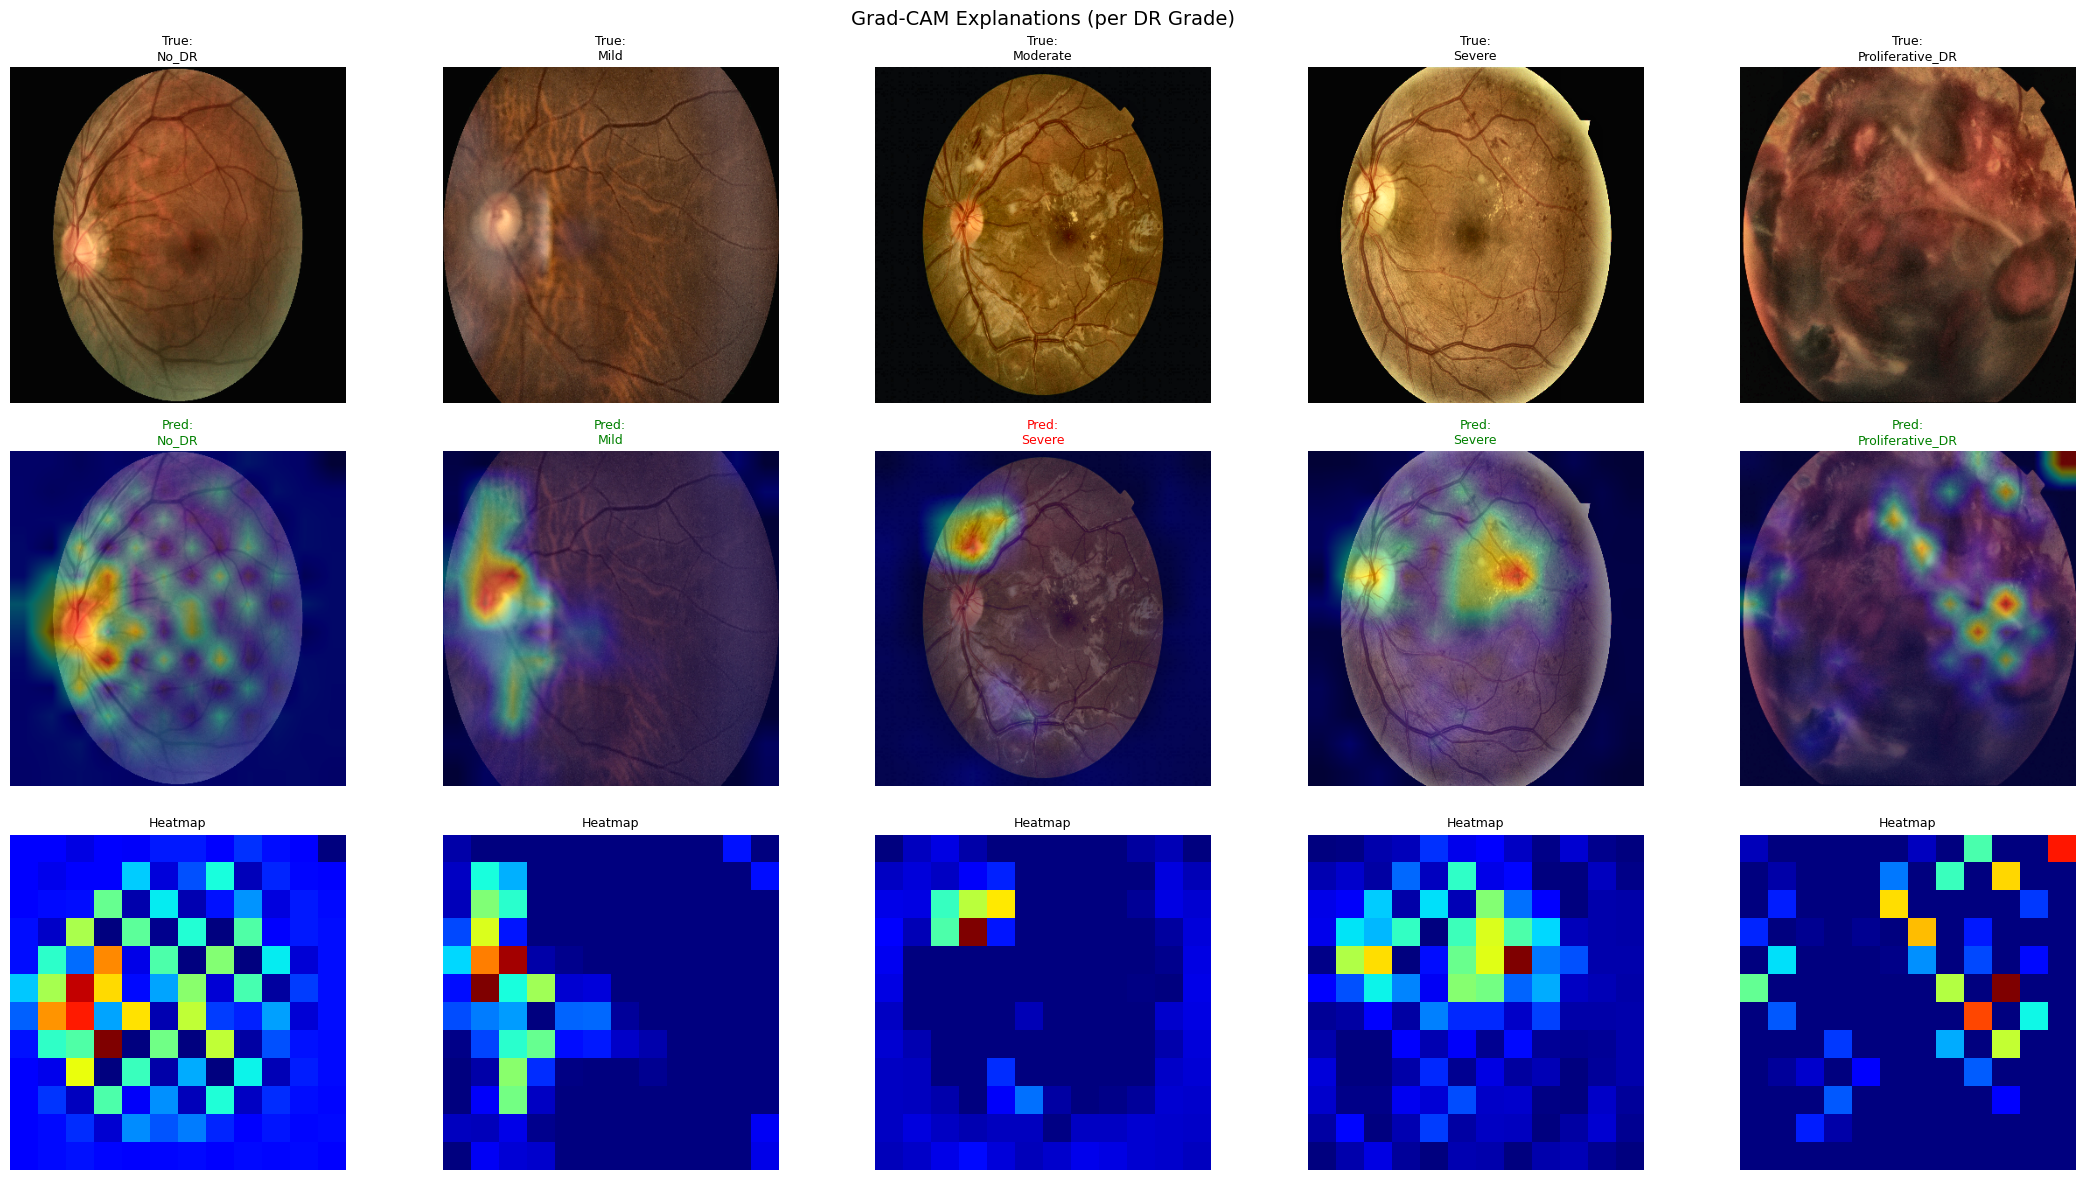

Grad-CAM complete.


In [ ]:
import cv2

# ── Find one example per class by scanning multiple batches ──────────────────
class_examples = {}

for images, labels in val_ds:
    imgs_f32 = tf.cast(images, tf.float32).numpy()
    lbls_f32 = tf.cast(labels, tf.float32).numpy()
    for i, lbl in enumerate(lbls_f32):
        cls = int(np.argmax(lbl))
        if cls not in class_examples:
            class_examples[cls] = imgs_f32[i:i+1]
    if len(class_examples) == NUM_CLASSES:
        break

print("Classes found:", {CLASS_NAMES[k]: v.shape for k, v in class_examples.items()})


# ── Grad-CAM ──────────────────────────────────────────────────────────────────
def get_gradcam_heatmap(img_array, outer_model, conv_layer_name='top_activation'):
    efficientnet = outer_model.layers[1]
    conv_out = efficientnet.get_layer(conv_layer_name).output

    x = conv_out
    for layer in outer_model.layers[2:]:
        x = layer(x)

    grad_model = tf.keras.Model(inputs=efficientnet.input, outputs=[conv_out, x])

    img_float = tf.cast(img_array, tf.float32)
    with tf.GradientTape() as tape:
        conv_outputs, predictions = grad_model(img_float, training=False)
        pred_index  = tf.argmax(predictions[0])
        class_score = predictions[:, pred_index]

    grads        = tape.gradient(class_score, conv_outputs)
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))
    weighted     = conv_outputs[0] * pooled_grads[tf.newaxis, tf.newaxis, :]
    heatmap      = tf.reduce_sum(weighted, axis=-1)
    heatmap      = tf.maximum(heatmap, 0)
    heatmap      = heatmap / (tf.math.reduce_max(heatmap) + 1e-8)

    # ── CRITICAL: cast to float32 — cv2.resize rejects float16 ──────────────
    return heatmap.numpy().astype(np.float32), int(pred_index.numpy())


def overlay_heatmap(img_array, heatmap, alpha=0.4):
    img      = np.clip(img_array[0], 0, 255).astype(np.uint8)
    hm       = cv2.resize(heatmap, (img.shape[1], img.shape[0]),
                          interpolation=cv2.INTER_LINEAR)          # float32 ✓
    hm_color = cv2.applyColorMap(np.uint8(255 * hm), cv2.COLORMAP_JET)
    hm_color = cv2.cvtColor(hm_color, cv2.COLOR_BGR2RGB)
    return cv2.addWeighted(img, 1 - alpha, hm_color, alpha, 0)


# ── Plot ──────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(3, NUM_CLASSES, figsize=(22, 12))
fig.suptitle('Grad-CAM Explanations (per DR Grade)', fontsize=14)

for cls in range(NUM_CLASSES):
    if cls not in class_examples:
        for r in range(3):
            axes[r, cls].text(0.5, 0.5, 'No sample\nin val_ds',
                              ha='center', va='center', fontsize=9,
                              transform=axes[r, cls].transAxes)
            axes[r, cls].axis('off')
        continue

    img = class_examples[cls]

    axes[0, cls].imshow(np.clip(img[0], 0, 255).astype(np.uint8))
    axes[0, cls].set_title(f'True:\n{CLASS_NAMES[cls]}', fontsize=9)
    axes[0, cls].axis('off')

    try:
        hm, pred_cls = get_gradcam_heatmap(img, best_model)

        axes[1, cls].imshow(overlay_heatmap(img, hm))
        axes[1, cls].set_title(
            f'Pred:\n{CLASS_NAMES[pred_cls]}', fontsize=9,
            color='green' if pred_cls == cls else 'red'
        )
        axes[2, cls].imshow(hm, cmap='jet')
        axes[2, cls].set_title('Heatmap', fontsize=9)

    except Exception as e:
        import traceback; traceback.print_exc()
        for r in range(1, 3):
            axes[r, cls].text(0.5, 0.5, f'Error:\n{str(e)[:60]}',
                              ha='center', va='center', fontsize=7,
                              transform=axes[r, cls].transAxes)

    for r in range(3):
        axes[r, cls].axis('off')

for r, lbl in enumerate(['Original', 'CAM Overlay', 'Heatmap']):
    axes[r, 0].set_ylabel(lbl, fontsize=11, rotation=90, labelpad=40)

plt.tight_layout()
plt.savefig('gradcam_all_class.png', dpi=150)
plt.show()
print('Grad-CAM complete.')

In [ ]:
# ── CELL 20 — TTA (fixed: raw [0,255] to model, QWK comparison) ──────────────
# Original bug: TTA was calling model.predict(aug_imgs) where aug_imgs came
# from val_ds which is already [0,255]. That is correct. But we also collect
# probs now so we can compute QWK, not just accuracy.

def predict_with_tta(model, dataset, n_augments=5):
    """
    Test-Time Augmentation. Images stay in [0,255] — consistent with training.
    Returns y_true, y_pred, y_prob_avg for downstream QWK computation.
    """
    tta_aug = tf.keras.Sequential([
        tf.keras.layers.RandomFlip('horizontal_and_vertical'),
        tf.keras.layers.RandomRotation(0.1),
        tf.keras.layers.RandomZoom(0.05),
    ])

    y_true_tta, y_prob_tta = [], []

    for images, labels in dataset:
        images = tf.cast(images, tf.float32)   # mixed-precision safety
        batch_preds = [model.predict(images, verbose=0)]   # original
        for _ in range(n_augments):
            aug = tta_aug(images, training=True)
            batch_preds.append(model.predict(aug, verbose=0))

        avg_preds = np.mean(batch_preds, axis=0)
        y_true_tta.extend(np.argmax(tf.cast(labels, tf.float32).numpy(), axis=1))
        y_prob_tta.extend(avg_preds)

    y_true_tta = np.array(y_true_tta)
    y_prob_tta = np.array(y_prob_tta)
    y_pred_tta = np.argmax(y_prob_tta, axis=1)
    return y_true_tta, y_pred_tta, y_prob_tta


print("Running TTA predictions (n_augments=5, takes a few minutes)...")
y_true_tta, y_pred_tta, y_prob_tta = predict_with_tta(best_model, val_ds, n_augments=5)

acc_tta  = np.mean(y_true_tta == y_pred_tta)
acc_base = np.mean(y_true_all == y_pred_all)
qwk_tta  = cohen_kappa_score(y_true_tta, y_pred_tta, weights='quadratic')

print(f"\nWithout TTA — Accuracy: {acc_base*100:.2f}%   QWK: {qwk_val:.4f}")
print(f"With    TTA — Accuracy: {acc_tta*100:.2f}%   QWK: {qwk_tta:.4f}")
print(f"TTA delta   — Accuracy: {(acc_tta-acc_base)*100:+.2f}%   QWK: {qwk_tta-qwk_val:+.4f}")
print()
print('TTA Classification Report:')
print(classification_report(y_true_tta, y_pred_tta, target_names=CLASS_NAMES, digits=3))

Running TTA predictions (n_augments=5, takes a few minutes)...

Without TTA — Accuracy: 77.83%   QWK: 0.8460
With    TTA — Accuracy: 78.91%   QWK: 0.8656
TTA delta   — Accuracy: +1.08%   QWK: +0.0197

TTA Classification Report:
                  precision    recall  f1-score   support

           No_DR      0.876     0.961     0.917      1253
            Mild      0.168     0.175     0.171       126
        Moderate      0.887     0.626     0.734       895
          Severe      0.207     0.660     0.315        47
Proliferative_DR      0.728     0.868     0.792       182

        accuracy                          0.789      2503
       macro avg      0.573     0.658     0.586      2503
    weighted avg      0.821     0.789     0.793      2503

